<a href="https://colab.research.google.com/github/pjastr-uwm/fakultet_io_2026/blob/main/lab03/lab03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Eksploracyjna analiza tekstu (EDA)


W tym notatniku przećwiczymy kluczowe etapy eksploracyjnej analizy tekstu:

1. Ładowanie i wstępny przegląd danych
2. Tokenizacja i obliczanie statystyk korpusu
3. Rozkład długości dokumentów
4. Type–Token Ratio (TTR)
5. Hapax legomena
6. Najczęstsze słowa (z i bez stop words)
7. Statystyki na poziomie dokumentu
8. Wizualizacja: chmury słów
9. Wizualizacja: histogramy częstości
10. N-gramy (bigramy i trigramy)
11. Prawo Zipfa

Do ćwiczeń wykorzystamy kilka zbiorów danych w języku polskim (pliki CSV).

---
## 0. Instalacja i import bibliotek

Zainstaluj wymagane pakiety (na Colabie wystarczy uruchomić poniższą komórkę).

In [9]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter

import nltk
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import word_tokenize
from nltk import ngrams
from wordcloud import WordCloud

# Polskie stop words — pobieramy z internetu
import urllib.request
url = "https://raw.githubusercontent.com/bieli/stopwords/master/polish.stopwords.txt"
response = urllib.request.urlopen(url)
stop_pl = set(response.read().decode("utf-8").splitlines())

print("Wszystko gotowe!")
print(f"Załadowano {len(stop_pl)} polskich stop words.")

Wszystko gotowe!
Załadowano 350 polskich stop words.


---
## 1. Ładowanie danych

Wgraj pliki CSV do Colaba (ikona folderu po lewej → Upload) lub użyj poniższego kodu do wgrania plików.

Dostępne zbiory danych:
- **`recenzje_filmowe.csv`** — recenzje filmów z etykietami sentymentu (pozytywna/negatywna)
- **`opinie_produktowe.csv`** — opinie o produktach ze sklepu internetowego (kategoria + ocena)
- **`recenzje_restauracji.csv`** — opinie o restauracjach (nazwa + ocena)

**Zadanie:** Załaduj wybrany zbiór danych do DataFrame i wyświetl kilka pierwszych wierszy. Sprawdź kolumny, rozmiar i typy danych.

In [5]:
# Wgrywanie plików na Colabie:
# from google.colab import files
# uploaded = files.upload()

# Załaduj wybrany plik CSV
# df = pd.read_csv("recenzje_filmowe.csv")
import pandas as pd
import numpy as np
df = pd.read_csv("recenzje_filmowe.csv")



In [6]:
# Wyświetl podstawowe informacje o zbiorze:
# - df.shape
# - df.columns
# - df.dtypes
# - df.head()
# - df["text"].head(3)
print(f"Kształt danych: {df.shape}")
print(f"Kolumny: {df.columns}")
print(f"Typy danych:\n{df.dtypes}")
print("\nPierwsze 5 wierszy:")
display(df.head())

df["text"].head(3)


Kształt danych: (40, 2)
Kolumny: Index(['text', 'label'], dtype='str')
Typy danych:
text     str
label    str
dtype: object

Pierwsze 5 wierszy:


,text,label
0,"Film był absolutnie wspaniały, gra aktorska na...",pozytywna
1,"Niestety, to jeden z najgorszych filmów jakie ...",negatywna
2,Świetne efekty specjalne i bardzo dobra muzyka...,pozytywna
3,"Kompletna strata czasu. Dialogi żenujące, scen...",negatywna
4,Bardzo dobry film familijny. Dzieci były zachw...,pozytywna


0    Film był absolutnie wspaniały, gra aktorska na...
1    Niestety, to jeden z najgorszych filmów jakie ...
2    Świetne efekty specjalne i bardzo dobra muzyka...
Name: text, dtype: str

---
## 2. Tokenizacja i podstawowe statystyki korpusu

Pierwszym krokiem EDA jest obliczenie **podstawowych metryk**:

| Metryka | Opis |
|---|---|
| Liczba dokumentów | Ile tekstów zawiera korpus |
| Łączna liczba tokenów | Suma tokenów we wszystkich dokumentach |
| Liczba unikalnych tokenów (typy) | Rozmiar słownika |
| Średnia długość dokumentu | Przeciętna liczba tokenów na dokument |
| Mediana długości | Odporniejsza na wartości odstające niż średnia |
| Min / Max długości | Rozpiętość |

**Zadanie:** Stokenizuj kolumnę `text` za pomocą `word_tokenize` (z parametrem `language="polish"`). Oblicz i wyświetl powyższe metryki.

In [50]:
# Tokenizacja
df["tokens"] = df["text"].apply(lambda x: word_tokenize(x, language="polish"))
df["n_tokens"] = df["tokens"].apply(len)
all_tokens = df["tokens"].explode().tolist()
# Wyświetl statystyki:
# - Liczba dokumentów
# - Łączna liczba tokenów
# - Unikalne tokeny (typy)
# - Średnia, mediana, min, max długości
print(f"Liczba dokumentów: {len(df)}")
print(f"Łączna liczba tokenów: {len(all_tokens)}")
print(f"Liczba unikalnych tokenów (typy): {len(set(all_tokens))}")
print(f"Średnia długość dokumentu: {df['n_tokens'].mean():.2f}")
print(f"Mediana długości: {df['n_tokens'].median()}")
print(f"Min / Max długości: {df['n_tokens'].min()} / {df['n_tokens'].max()}")


Liczba dokumentów: 40
Łączna liczba tokenów: 742
Liczba unikalnych tokenów (typy): 432
Średnia długość dokumentu: 18.55
Mediana długości: 18.0
Min / Max długości: 14 / 26


---
## 3. Rozkład długości dokumentów

Histogram długości dokumentów pozwala szybko ocenić **strukturę korpusu**.

Na co zwracać uwagę:
- **Skośność** — czy rozkład jest silnie prawostronny? (typowe dla tekstu)
- **Wartości odstające** — bardzo krótkie / bardzo długie dokumenty mogą wymagać filtrowania
- **Multimodalność** — dwa szczyty mogą sugerować dwa różne typy dokumentów

**Zadanie:** Narysuj histogram długości dokumentów (w tokenach). Dodaj linię mediany.

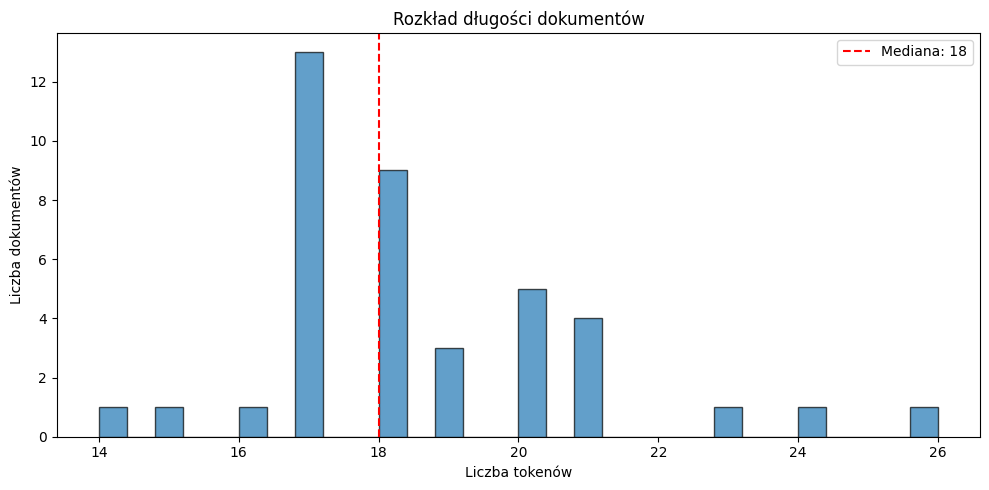

In [51]:
plt.figure(figsize=(10, 5))
plt.hist(df["n_tokens"], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel("Liczba tokenów")
plt.ylabel("Liczba dokumentów")
plt.title("Rozkład długości dokumentów")
plt.axvline(df["n_tokens"].median(), color="red", linestyle="--", label=f"Mediana: {df['n_tokens'].median():.0f}")
plt.legend()
plt.tight_layout()
plt.show()



---
## 4. Type–Token Ratio (TTR)

**TTR** = liczba unikalnych tokenów / łączna liczba tokenów

Mierzy **zróżnicowanie leksykalne** tekstu:
- TTR bliskie **1** → bogaty, różnorodny język (np. proza literacka)
- TTR bliskie **0** → powtarzalne, ograniczone słownictwo (np. instrukcje techniczne)

**Uwaga:** TTR zależy silnie od długości tekstu — dłuższe teksty mają niższy TTR.

**Zadanie:**
1. Zbierz wszystkie tokeny z korpusu w jedną listę.
2. Odfiltruj interpunkcję (zostaw tylko tokeny `isalpha()` i dłuższe niż 1 znak).
3. Znormalizuj do lowercase.
4. Oblicz TTR dla całego korpusu.

In [52]:
# Zbierz wszystkie tokeny
all_tokens = df["tokens"].explode().tolist()

# Filtrowanie i normalizacja
word_tokens = [t.lower() for t in all_tokens if t.isalpha() and len(t) > 1]

# Oblicz TTR
types = set(word_tokens)
ttr = len(types) / len(word_tokens)
print(ttr)


0.736936936936937


---
## 5. Hapax legomena

**Hapax legomenon** (gr. *raz powiedziane*) — słowo występujące w korpusie **dokładnie raz**.

Dlaczego to istotne:
- Hapax legomena stanowią zwykle **40–60% słownika**, ale ułamek procenta tokenów
- Są to często literówki, nazwiska, neologizmy, słowa specjalistyczne
- Pomagają ocenić **szum** w danych

**Zadanie:** Użyj `Counter` na liście `word_tokens` i znajdź słowa występujące dokładnie raz. Ile jest hapax legomena? Jaki procent słownika stanowią? Wyświetl kilka przykładów.

In [53]:
freq = Counter(word_tokens)
hapax = [w for w, c in freq.items() if c == 1]
print(f"Przykładowe hapaxy: {hapax[:10]}")
# Ile hapaxów? Jaki procent słownika?
# Wyświetl przykłady.



Przykładowe hapaxy: ['absolutnie', 'wspaniały', 'aktorska', 'najwyższym', 'stworzył', 'dzieło', 'długo', 'pozostanie', 'pamięci', 'każdemu']


---
## 6. Najczęstsze słowa

Lista najczęstszych słów pozwala szybko ocenić **charakter korpusu**.

Typowe obserwacje:
- Na szczycie są **stop words**: „i", „w", „na", „z", „nie", „to", „się"
- Po usunięciu stop words pojawiają się słowa **dziedzinowe** — to wartościowa informacja

**Zadanie:**
1. Wyświetl top 20 najczęstszych słów **ze** stop words (z prostym wykresem słupkowym w terminalu).
2. Stwórz nowy `Counter` **bez** stop words i wyświetl top 20.

In [54]:
# Top 20 ze stop words
for word, count in freq.most_common(20):
    print(f"{word}: {count}")



film: 19
nie: 16
jest: 11
na: 10
się: 9
do: 6
nic: 5
reżyser: 4
aktorzy: 4
kino: 4
który: 4
to: 3
fabuła: 3
bez: 3
bardzo: 3
scenariusz: 3
dzieci: 3
ale: 3
przez: 3
sceny: 3


In [55]:
# Top 20 BEZ stop words
tokens_no_stop = [t for t in word_tokens if t not in stop_pl]
freq_no_stop = Counter(tokens_no_stop)
for word, count in freq_no_stop.most_common(20):
    print(f"{word}: {count}")



film: 19
reżyser: 4
aktorzy: 4
kino: 4
fabuła: 3
scenariusz: 3
dzieci: 3
sceny: 3
gra: 2
poziomie: 2
widza: 2
polecam: 2
niestety: 2
filmów: 2
efekty: 2
specjalne: 2
muzyka: 2
obejrzeć: 2
ekranie: 2
kompletna: 2


---
## 7. Statystyki na poziomie dokumentu

Warto badać nie tylko cały korpus, ale także **rozkłady wewnątrz dokumentów**:

- **TTR per dokument** — zróżnicowanie leksykalne każdego tekstu
- **Średnia długość słowa** — krótsze słowa mogą sugerować prostszy język
- **Udział stop words** — jaki procent tokenów to słowa funkcyjne

Takie metryki mogą służyć jako **cechy (features)** w klasyfikacji dokumentów.

**Zadanie:** Dla każdego dokumentu oblicz TTR, średnią długość słowa i udział stop words. Wyświetl statystyki opisowe (`describe()`).

In [56]:
df["ttr"] = df["tokens"].apply(lambda t: len(set(t)) / len(t) if len(t) > 0 else 0)
df["avg_word_len"] = df["tokens"].apply(lambda t: sum(len(w) for w in t) / len(t) if len(t) > 0 else 0)
df["stop_ratio"] = df["tokens"].apply(lambda t: sum(1 for w in t if w in stop_pl) / len(t) if len(t) > 0 else 0)

print(df[["n_tokens", "ttr", "avg_word_len", "stop_ratio"]].describe())



        n_tokens        ttr  avg_word_len  stop_ratio
count  40.000000  40.000000     40.000000   40.000000
mean   18.550000   0.899282      5.097693    0.249328
std     2.341926   0.042864      0.591590    0.086208
min    14.000000   0.761905      3.714286    0.071429
25%    17.000000   0.882353      4.696078    0.191850
50%    18.000000   0.897368      5.222222    0.235294
75%    20.000000   0.941176      5.411765    0.294118
max    26.000000   0.950000      6.500000    0.421053


---
## 8. Wizualizacja: chmury słów

Chmura słów to popularna (choć uproszczona) metoda wizualizacji częstości:
- Rozmiar słowa ∝ jego częstość
- **Ograniczenia:** brak precyzji, trudność porównywania

Ciekawsza technika: **chmury porównawcze** między kategoriami (np. recenzje pozytywne vs. negatywne).

**Zadanie:**
1. Wygeneruj chmurę słów dla całego korpusu (z `stopwords=stop_pl`).
2. *(Dla zbiorów z etykietami)* Wygeneruj osobne chmury dla różnych kategorii.

In [57]:
# Chmura słów dla całego korpusu
# text_all = " ".join(word_tokens)
# wc = WordCloud(width=800, height=400,
#                background_color="white",
#                max_words=150,
#                colormap="viridis",
#                stopwords=stop_pl)
# wc.generate(text_all)
#
# plt.figure(figsize=(12, 6))
# plt.imshow(wc, interpolation="bilinear")
# plt.axis("off")
# plt.title("Chmura słów")
# plt.show()



In [58]:
# Chmury porównawcze (np. pozytywne vs. negatywne recenzje)
# Wskazówka: odfiltruj df po kolumnie etykiety,
# zbierz tokeny osobno dla każdej grupy,
# narysuj dwie chmury obok siebie (fig, axes = plt.subplots(1, 2, ...))



---
## 9. Wizualizacja: histogramy częstości

Wykres słupkowy top-N słów jest bardziej **precyzyjny** niż chmura.

**Zadanie:** Narysuj poziomy wykres słupkowy (`barh`) z 25 najczęstszymi słowami (bez stop words).

In [59]:
# top_words = freq_no_stop.most_common(25)
# words, counts = zip(*top_words)
#
# plt.figure(figsize=(12, 6))
# plt.barh(range(len(words)), counts, color="steelblue")
# plt.yticks(range(len(words)), words)
# plt.xlabel("Częstość")
# plt.title("25 najczęstszych słów (bez stop words)")
# plt.gca().invert_yaxis()
# plt.tight_layout()
# plt.show()



---
## 10. N-gramy

Analiza pojedynczych słów (unigramów) nie chwyta **fraz** i **kolokacji**.

**N-gram** — ciąg n kolejnych tokenów:
- **Bigram:** „nie lubię", „bardzo dobry", „efekty specjalne"
- **Trigram:** „nie do końca", „na pewno nie", „jeden z najlepszych"

**Zadanie:**
1. Wygeneruj bigramy z `word_tokens` (użyj `nltk.ngrams`).
2. Wyświetl top 15 bigramów.
3. Odfiltruj bigramy zawierające stop words i wyświetl top 15 ponownie.
4. *(Opcjonalnie)* Zrób to samo dla trigramów.

In [60]:
# Bigramy — wszystkie
# bigrams = list(ngrams(word_tokens, 2))
# bigram_freq = Counter(bigrams)



In [61]:
# Bigramy — bez stop words
# bigrams_filtered = [(a, b) for a, b in bigrams if a not in stop_pl and b not in stop_pl]
# bigram_freq_f = Counter(bigrams_filtered)



In [62]:
# (Opcjonalnie) Trigramy



---
## 11. Prawo Zipfa

**George Kingsley Zipf** (1935) zauważył regularność: jeśli posortujemy słowa od najczęstszego do najrzadszego i przypiszemy im **rangi** (1, 2, 3, …), to:

$$f(r) \approx \frac{C}{r^\alpha}$$

gdzie f(r) to częstość słowa o randze r, C to stała, α ≈ 1.

Inaczej: **ranga × częstość ≈ const**.

Konsekwencje:
- Nieliczne słowa dominują — 100 najczęstszych słów pokrywa zwykle 50%+ tekstu
- Ogon rozkładu jest długi — tysiące słów pojawiają się 1–2 razy

**Zadanie:**
1. Posortuj częstości malejąco i przypisz rangi.
2. Narysuj wykres **log-log** (ranga vs. częstość).
3. Dodaj linię teoretyczną Zipfa (α=1).
4. Oblicz, jaki procent wszystkich tokenów pokrywają top-100 i top-1000 słów.

In [63]:
# Wykres log-log prawa Zipfa
# ranks = range(1, len(freq) + 1)
# frequencies = sorted(freq.values(), reverse=True)
#
# plt.figure(figsize=(10, 6))
# plt.loglog(ranks, frequencies, linewidth=0.8)
# plt.xlabel("Ranga (log)")
# plt.ylabel("Częstość (log)")
# plt.title("Prawo Zipfa — wykres log-log")
# plt.grid(True, alpha=0.3)
#
# # Linia teoretyczna
# C = frequencies[0]
# zipf_theoretical = [C / r for r in ranks]
# plt.loglog(ranks, zipf_theoretical, "--", color="red", label="Zipf teoretyczny (α=1)", alpha=0.7)
# plt.legend()
# plt.tight_layout()
# plt.show()



In [64]:
# Pokrycie top-N słów
# top100 = freq.most_common(100)
# coverage = sum(c for _, c in top100) / sum(freq.values())
# print(f"Top 100 słów pokrywa {coverage*100:.1f}% wszystkich tokenów")



---
## 12. Zadania dodatkowe

Poniżej kilka dodatkowych zadań do samodzielnego rozwiązania:

### Zadanie A: Porównanie zbiorów
Załaduj **dwa różne** pliki CSV (np. `recenzje_filmowe.csv` i `recenzje_restauracji.csv`). Porównaj:
- Średnią długość dokumentu
- TTR korpusu
- Liczbę hapax legomena
- Top 10 słów (bez stop words)

### Zadanie B: Analiza sentymentu — różnice słownikowe
Dla zbioru `recenzje_filmowe.csv`:
1. Podziel recenzje na pozytywne i negatywne.
2. Dla każdej grupy oblicz top 20 słów (bez stop words).
3. Które słowa występują **tylko** w recenzjach pozytywnych? A które **tylko** w negatywnych?

### Zadanie C: Strefy Zipfa (Luhn)
Na podstawie wykresu Zipfa z zadania 11:
1. Zidentyfikuj **górną strefę** (stop words — zbyt częste).
2. Zidentyfikuj **dolną strefę** (hapax legomena — zbyt rzadkie).
3. Wypisz słowa ze **środkowej strefy** — potencjalnie najcenniejsze informacyjnie.

In [65]:
# Miejsce na zadanie A



In [66]:
# Miejsce na zadanie B



In [67]:
# Miejsce na zadanie C

